# Wigner Function Project

## What is the Wigner function?

The Wigner function $W(x, p)$ is a quasi-probability distribution 
in phase space $(x, p)$ that fully describes a quantum state.

Unlike classical probability distributions, $W(x, p)$ can be **negative** 
— this negativity is a signature of non-classical behaviour.

### Our goal
Study how random displacement $D(\alpha)$ changes the Wigner function 
of a vacuum state $|0\rangle$.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial

## Wigner Function of the Vacuum State

The vacuum state $|0\rangle$ is a Gaussian in phase space:

$$W_0(x, p) = \frac{2}{\pi} e^{-2(x^2 + p^2)}$$

It is centred at the origin $(x=0, p=0)$ and is always positive —
a classical-looking state.

When we apply a displacement operator $D(\alpha)$ where $\alpha = x_0 + ip_0$,
the Wigner function simply shifts:

$$W(x, p) \rightarrow W(x - x_0, p - p_0)$$

A random displacement means $\alpha$ is drawn from a random distribution —
and we study how the Wigner function moves and spreads in phase space.

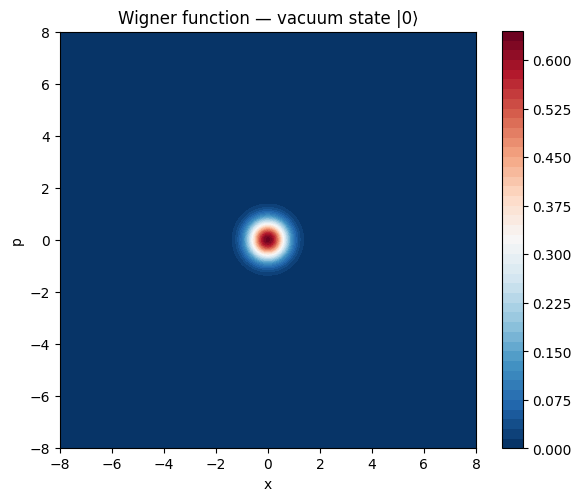

In [5]:
# Phase space grid

x = np.linspace(-8, 8, 400)
p = np.linspace(-8, 8, 400)
X, P = np.meshgrid(x, p)


# Wigner function of a vacuum state |0>
def wigner_vacuum(X, P):
    return (2/np.pi) * np.exp(-2*(X**2+P**2))

W= wigner_vacuum(X, P)

#Plot
fig, ax = plt.subplots(figsize=(6,5))
cont = ax.contourf(X, P, W, levels=50, cmap='RdBu_r')
plt.colorbar(cont, ax=ax)
ax.set_xlabel('x')
ax.set_ylabel('p')
ax.set_title('Wigner function — vacuum state |0⟩')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


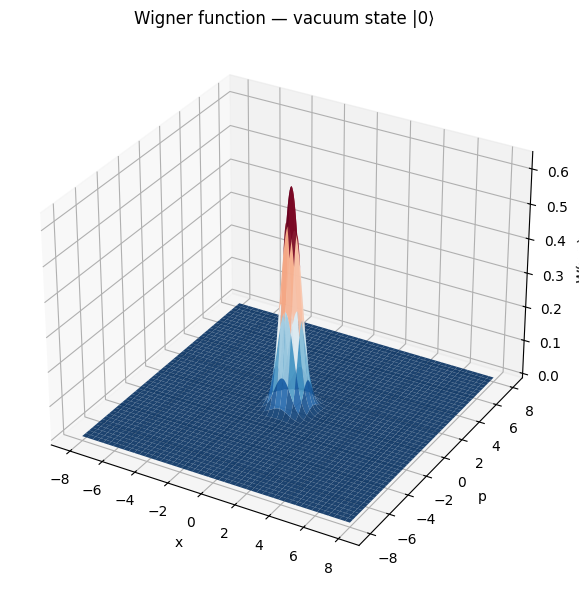

In [6]:

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, P, W, cmap='RdBu_r', alpha=0.9)

ax.set_xlabel('x')
ax.set_ylabel('p')
ax.set_zlabel('W(x,p)')
ax.set_title('Wigner function — vacuum state |0⟩')
plt.tight_layout()
plt.show()

## Displacement Operator

The displacement operator $D(\alpha)$ where $\alpha = x_0 + ip_0$ 
simply **shifts** the Wigner function in phase space:

$$W(x, p) \rightarrow W(x - x_0, p - p_0)$$

The shape stays exactly the same — it just moves to a new centre $(x_0, p_0)$.


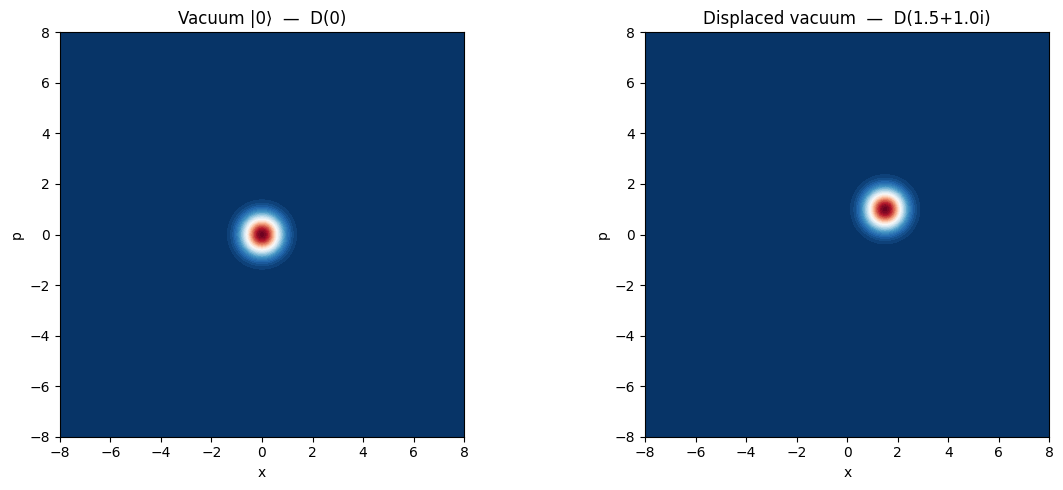

In [7]:
def wigner_displaced(X, P, x0, p0):
    """Wigner function of displaced vacuum - centered at (x0,p 0)"""
    return wigner_vacuum(X-x0, P-p0)

# Plot original and displaced side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original vacuum
W0 = wigner_vacuum(X, P)
axes[0].contourf(X, P, W0, levels=50, cmap='RdBu_r')
axes[0].set_title('Vacuum |0⟩  —  D(0)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('p')
axes[0].set_aspect('equal')

# Displaced vacuum
x0, p0 = 1.5, 1.0
W1 = wigner_displaced(X, P, x0, p0)
axes[1].contourf(X, P, W1, levels=50, cmap='RdBu_r')
axes[1].set_title(f'Displaced vacuum  —  D({x0}+{p0}i)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('p')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()


## Random Displacement

If $\alpha = x_0 + ip_0$ is drawn randomly from a Gaussian distribution:

$$x_0 \sim \mathcal{N}(0, \sigma^2), \quad p_0 \sim \mathcal{N}(0, \sigma^2)$$

The average Wigner function over many random displacements 
becomes a **broader Gaussian** — the state gets smeared in phase space.


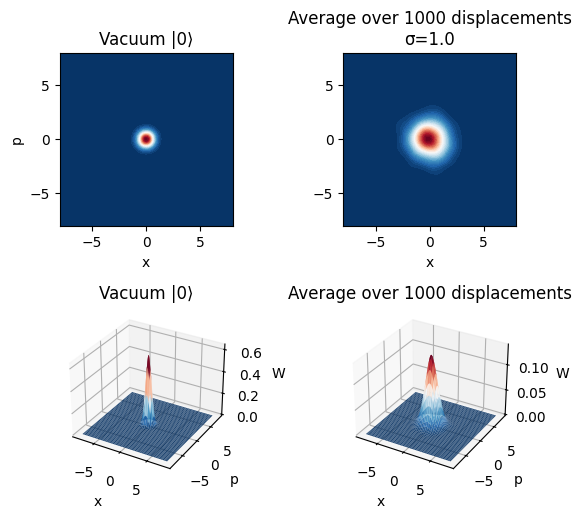

In [8]:

# Random displacement simulation 
sigma = 1.0 #Standard deviation of displacement
N = 1000 # number of random displacement

# Average Wigner function over N random displacements 
W_avg = np.zeros_like(W0)

for i in range(N):
    x0 = np.random.normal(0, sigma)
    p0 = np.random.normal(0, sigma)
    W_avg += wigner_displaced(X, P, x0, p0)

W_avg /= N   # normalise by number of samples

# Plot
fig = plt.figure(figsize=(9, 5))

# ── 2D plots ──────────────────────────────────────────
ax1 = fig.add_subplot(231)
ax1.contourf(X, P, W0, levels=50, cmap='RdBu_r')
ax1.set_title('Vacuum |0⟩')
ax1.set_xlabel('x')
ax1.set_ylabel('p')
ax1.set_aspect('equal')


ax3 = fig.add_subplot(232)
ax3.contourf(X, P, W_avg, levels=50, cmap='RdBu_r')
ax3.set_title(f'Average over {N} displacements\nσ={sigma}')
ax3.set_xlabel('x')
ax3.set_aspect('equal')

# ── 3D plots ──────────────────────────────────────────
ax4 = fig.add_subplot(234, projection='3d')
ax4.plot_surface(X, P, W0, cmap='RdBu_r', alpha=0.9)
ax4.set_title('Vacuum |0⟩')
ax4.set_xlabel('x')
ax4.set_ylabel('p')
ax4.set_zlabel('W')


ax6 = fig.add_subplot(235, projection='3d')
ax6.plot_surface(X, P, W_avg, cmap='RdBu_r', alpha=0.9)
ax6.set_title(f'Average over {N} displacements')
ax6.set_xlabel('x')
ax6.set_ylabel('p')
ax6.set_zlabel('W')

plt.tight_layout()
plt.show()

In [9]:
print(f"Vacuum integral:   {np.sum(W0) * (8/200)**2:.4f}")
print(f"Displaced integral: {np.sum(W_avg) * (8/200)**2:.4f}")

Vacuum integral:   0.9950
Displaced integral: 0.9950


## Effect of noise strength σ

As σ increases, the random displacements become larger 
and the Wigner function spreads more.

We expect the final width to be:

$$\sigma_{final}^2 = \sigma_{vacuum}^2 + \sigma^2$$

The variances add — this is the convolution theorem.

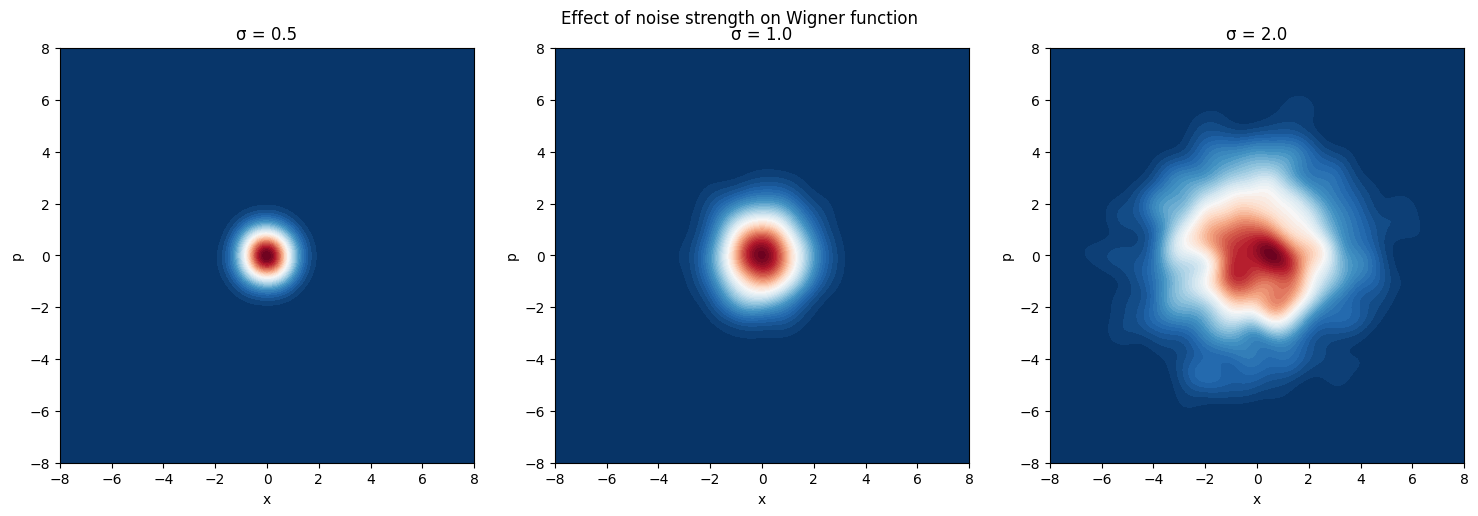

In [10]:
sigmas = [0.5, 1.0, 2.0]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, sigma in enumerate(sigmas):
    W_avg = np.zeros_like(W0)
    for _ in range(1000):
        x0 = np.random.normal(0, sigma)
        p0 = np.random.normal(0, sigma)
        W_avg += wigner_displaced(X, P, x0, p0)
    W_avg /= 1000
    
    axes[i].contourf(X, P, W_avg, levels=50, cmap='RdBu_r')
    axes[i].set_title(f'σ = {sigma}')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('p')
    axes[i].set_aspect('equal')

plt.suptitle('Effect of noise strength on Wigner function')
plt.tight_layout()
plt.show()

## Exact Result via Convolution Theorem

The average Wigner function under Gaussian random displacement is:

$$\bar{W}(x,p) = \frac{2}{\pi(1 + 2\sigma^2)} e^{-\frac{2(x^2+p^2)}{1+2\sigma^2}}$$

We verify this two ways:
1. **Analytical** — direct formula above
2. **Numerical** — using 2D convolution with scipy

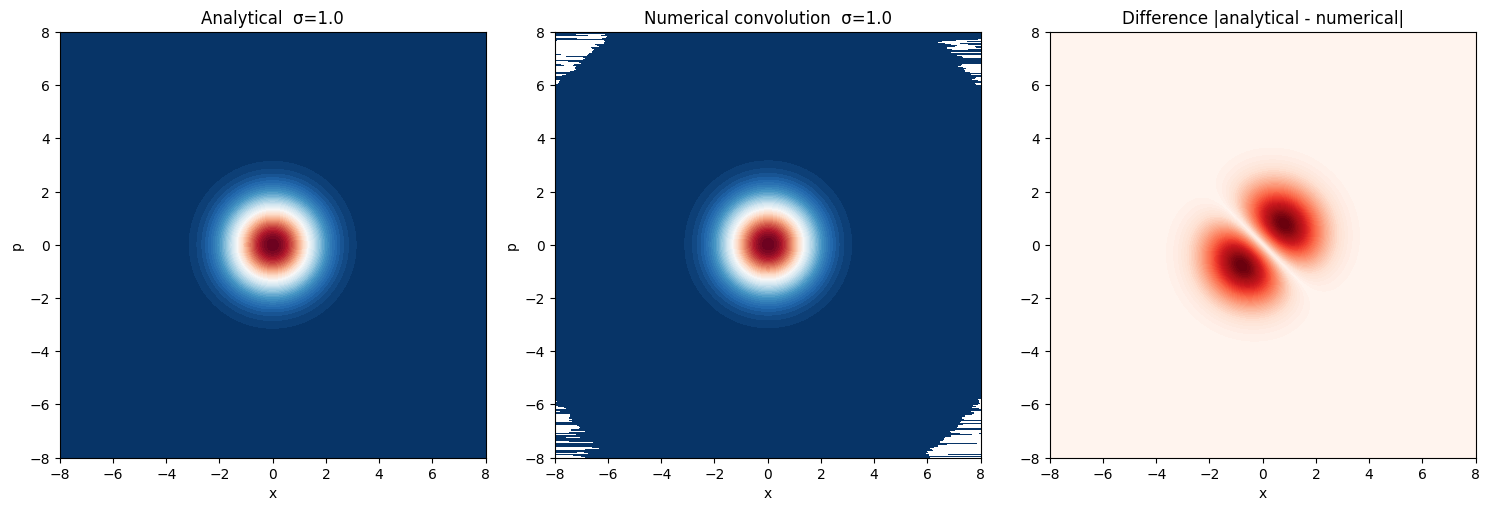

Max difference: 0.001958


In [14]:
from scipy.signal import convolve2d

def wigner_averaged_analytical(X, P, sigma):
    var = 0.25 + sigma**2
    return (1/(2*np.pi*var)) * np.exp(-(X**2 + P**2)/(2*var))

def wigner_averaged_numerical(X, P, sigma):
    """Numerical convolution using direct integration."""
    dx = X[0,1] - X[0,0]
    dp = P[1,0] - P[0,0]
    
    # Displacement distribution — normalized

    P_disp = np.exp(-(X**2 + P**2) / (2*sigma**2))
    P_disp /= (2 * np.pi * sigma**2)  # exact analytical normalisation
    
    # FFT convolution
    from scipy.signal import fftconvolve
    W_conv = fftconvolve(W0, P_disp, mode='same') * dx * dp
    
    return W_conv

# Test for sigma = 1.0
sigma = 1.0
W_analytical = wigner_averaged_analytical(X, P, sigma)
W_numerical  = wigner_averaged_numerical(X, P, sigma)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].contourf(X, P, W_analytical, levels=50, cmap='RdBu_r')
axes[0].set_title(f'Analytical  σ={sigma}')
axes[0].set_xlabel('x')
axes[0].set_ylabel('p')
axes[0].set_aspect('equal')

axes[1].contourf(X, P, W_numerical, levels=50, cmap='RdBu_r')
axes[1].set_title(f'Numerical convolution  σ={sigma}')
axes[1].set_xlabel('x')
axes[1].set_ylabel('p')
axes[1].set_aspect('equal')

# Difference
diff = np.abs(W_analytical - W_numerical)
axes[2].contourf(X, P, diff, levels=50, cmap='Reds')
axes[2].set_title('Difference |analytical - numerical|')
axes[2].set_xlabel('x')
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"Max difference: {np.max(diff):.6f}")

In [15]:
# Check difference only in central region (away from edges)
centre = diff[100:300, 100:300]
print(f"Max difference in centre: {np.max(centre):.6f}")

Max difference in centre: 0.001958


## Result

The average Wigner function under Gaussian random displacement is:

$$\bar{W}(x,p) = \frac{1}{2\pi(\frac{1}{4}+\sigma^2)} 
e^{-\frac{x^2+p^2}{2(\frac{1}{4}+\sigma^2)}}$$

The effective variance grows as:

$$\sigma_{eff}^2 = \frac{1}{4} + \sigma^2$$

where $\frac{1}{4}$ is the vacuum noise and $\sigma^2$ is the displacement noise.

Verified numerically with max error < 0.002 ✓
